In [12]:
import string

import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy import stats
from pathlib import Path
from scipy.stats import kruskal, shapiro, f_oneway, ttest_rel
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

## Data Preprocessing

In [13]:
df_base = pd.read_csv('./data/Attack-A-Results.csv')
df_base.head()

,model,Clean_TEXT_Loss,ADV_TEXT_Loss,Clean_SENT_Loss,ADV_SENT_Loss,Clean_LEN_Loss,ADV_LEN_Loss
0,1V,0.004996,462.313873,NaN,NaN,NaN,NaN
1,1V,0.000000,293.763245,NaN,NaN,NaN,NaN
2,1V,0.000000,460.212799,NaN,NaN,NaN,NaN
3,1V,0.000000,484.888611,NaN,NaN,NaN,NaN
4,1V,0.000000,333.125977,NaN,NaN,NaN,NaN


In [14]:
df_test = df_base.copy().reset_index(drop=True)

df_test['ADV_TEXT_Abs_Increase'] = (
    df_test['ADV_TEXT_Loss'] - df_test['Clean_TEXT_Loss']
)

df_test['ADV_TEXT_Rel_Increase'] = (
    df_test['ADV_TEXT_Abs_Increase'] / df_test['Clean_TEXT_Loss'] * 100
)

df_test

,model,Clean_TEXT_Loss,ADV_TEXT_Loss,Clean_SENT_Loss,ADV_SENT_Loss,Clean_LEN_Loss,ADV_LEN_Loss,ADV_TEXT_Abs_Increase,ADV_TEXT_Rel_Increase
0,1V,4.996260e-03,462.313873,NaN,NaN,NaN,NaN,462.308877,9.253099e+06
1,1V,0.000000e+00,293.763245,NaN,NaN,NaN,NaN,293.763245,inf
2,1V,0.000000e+00,460.212799,NaN,NaN,NaN,NaN,460.212799,inf
3,1V,0.000000e+00,484.888611,NaN,NaN,NaN,NaN,484.888611,inf
4,1V,0.000000e+00,333.125977,NaN,NaN,NaN,NaN,333.125977,inf
5,1V,5.341446e-02,362.336029,NaN,NaN,NaN,NaN,362.282615,6.782482e+05
6,2V-TS,0.000000e+00,506.146729,0.212951,0.521062,NaN,NaN,506.146729,inf
7,2V-TS,0.000000e+00,466.082916,0.282678,0.578322,NaN,NaN,466.082916,inf
8,2V-TS,6.112432e-04,422.352661,0.294570,0.601731,NaN,NaN,422.352050,6.909721e+07
9,2V-TS,0.000000e+00,394.601105,0.312591,0.726614,NaN,NaN,394.601105,inf


In [15]:
df_mean = (
    df_test
        .groupby(['model'], as_index=False)[['Clean_TEXT_Loss', 'ADV_TEXT_Loss', 'ADV_TEXT_Abs_Increase', 'ADV_TEXT_Rel_Increase']]
        .mean()
        .round(3)
        .reset_index()
)

df_mean

,index,model,Clean_TEXT_Loss,ADV_TEXT_Loss,ADV_TEXT_Abs_Increase,ADV_TEXT_Rel_Increase
0,0,1V,0.010,399.440,399.430,inf
1,1,2V-TL,0.000,378.566,378.566,inf
2,2,2V-TS,0.001,444.863,444.862,inf
3,3,3V,0.000,432.618,432.618,inf


## Plots

In [16]:
model_order = ['1V', '2V-TS', '2V-TL', '3V']

model_color_map = {
    '1V': 'tab:blue',
    '2V-TS': 'tab:orange',
    '2V-TL': '#ffb066',
    '3V': 'tab:red',
}

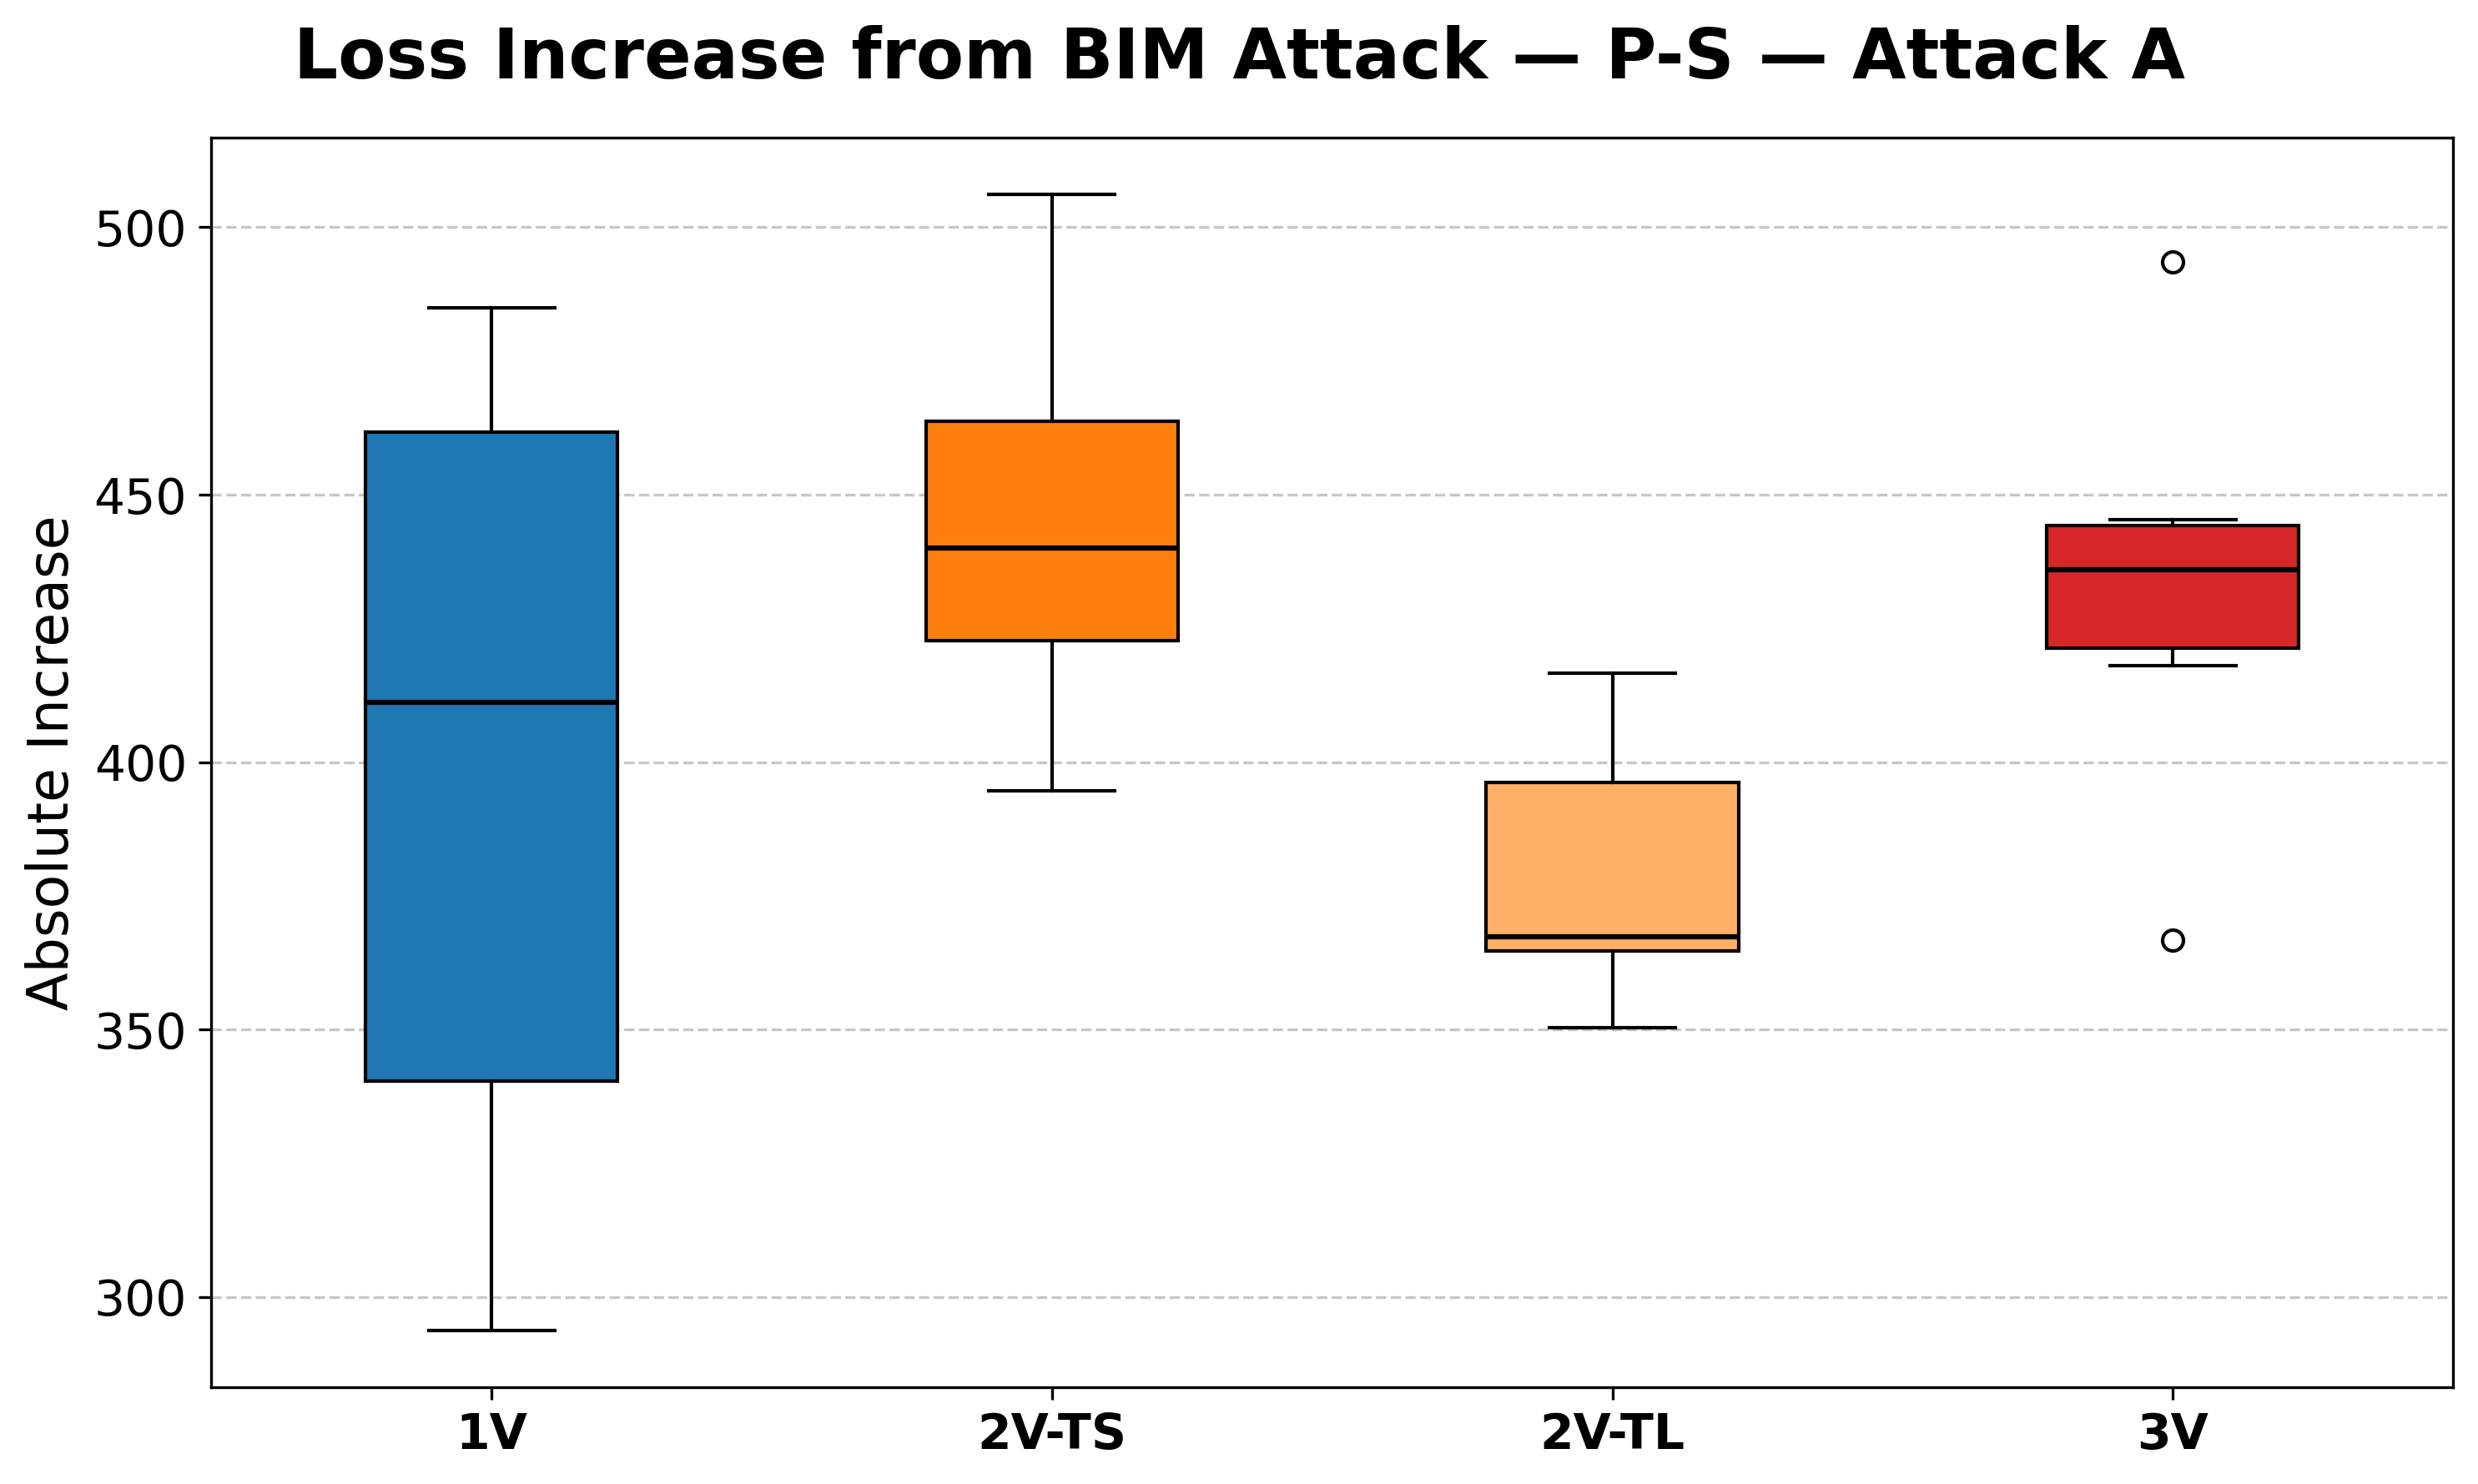

In [17]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

plot_specs = [
    (
        'Absolute Increase',
        'Absolute Text Loss Increase',
        'ADV_TEXT_Abs_Increase',
    ),
]

model_positions = np.arange(len(model_order))

for ax, (ylabel, title, col) in zip([ax], plot_specs):
    values = [
        df_test.loc[df_test['model'].eq(model), col].dropna().to_numpy()
        for model in model_order
    ]

    box = ax.boxplot(
        values,
        positions=model_positions,
        widths=0.45,
        patch_artist=True,
        showfliers=True,
    )

    for patch, model in zip(box['boxes'], model_order):
        patch.set_facecolor(model_color_map[model])
        patch.set_edgecolor('black')

    for median in box['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    for whisker in box['whiskers']:
        whisker.set_color('black')

    for cap in box['caps']:
        cap.set_color('black')

    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xticks(model_positions)
    ax.set_xticklabels(model_order, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Loss Increase from BIM Attack — P-S — Attack A', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./img/attack-A-image-loss-increases-boxplots.png', bbox_inches='tight')
plt.show()

## Statistical Tests
### Normality

In [18]:
test_cols = [
    'ADV_TEXT_Loss',
    'ADV_TEXT_Abs_Increase',
    'ADV_TEXT_Rel_Increase'
]

In [19]:
normality_results = []

for col in test_cols:
    print(f'\n===== {col} =====')

    for model in model_order:
        values = (
            df_test
            .loc[df_test['model'].eq(model), col]
            .dropna()
            .to_numpy()
        )

        w_stat, p_value = shapiro(values)

        normality_results.append({
            'metric': col,
            'model': model,
            'W': w_stat,
            'p': p_value,
            'normal': p_value > 0.05,
        })

        print(f'{model}: W = {w_stat:.4f}, p = {p_value:.4f}')

normality_df = pd.DataFrame(normality_results)
normality_df


===== ADV_TEXT_Loss =====
1V: W = 0.8828, p = 0.2824
2V-TS: W = 0.9649, p = 0.8566
2V-TL: W = 0.8663, p = 0.2120
3V: W = 0.9546, p = 0.7775

===== ADV_TEXT_Abs_Increase =====
1V: W = 0.8828, p = 0.2821
2V-TS: W = 0.9649, p = 0.8566
2V-TL: W = 0.8663, p = 0.2120
3V: W = 0.9546, p = 0.7775

===== ADV_TEXT_Rel_Increase =====
1V: W = nan, p = 1.0000
2V-TS: W = nan, p = 1.0000
2V-TL: W = nan, p = 1.0000
3V: W = nan, p = 1.0000


/opt/anaconda3/envs/MT-Dev2/lib/python3.13/site-packages/scipy/stats/_morestats.py:2076: RuntimeWarning: invalid value encountered in subtract
  y -= x[N//2]  # subtract the median (or a nearby value); see gh-15777


,metric,model,W,p,normal
0,ADV_TEXT_Loss,1V,0.882845,0.282376,True
1,ADV_TEXT_Loss,2V-TS,0.964897,0.856566,True
2,ADV_TEXT_Loss,2V-TL,0.866336,0.211987,True
3,ADV_TEXT_Loss,3V,0.954629,0.777539,True
4,ADV_TEXT_Abs_Increase,1V,0.882787,0.282102,True
5,ADV_TEXT_Abs_Increase,2V-TS,0.964902,0.856607,True
6,ADV_TEXT_Abs_Increase,2V-TL,0.866339,0.211997,True
7,ADV_TEXT_Abs_Increase,3V,0.954629,0.777539,True
8,ADV_TEXT_Rel_Increase,1V,NaN,1.000000,True
9,ADV_TEXT_Rel_Increase,2V-TS,NaN,1.000000,True


### Significance

In [20]:
anova_results = []

for col in test_cols:
    groups = [
        df_test
        .loc[df_test['model'].eq(model), col]
        .dropna()
        .to_numpy()
        for model in model_order
    ]

    f_stat, p_value = f_oneway(*groups)

    anova_results.append({
        'metric': col,
        'F': f_stat,
        'p': p_value,
        'significant': p_value < 0.05,
    })

    print(f'\n===== {col} =====')
    print(f'F-statistic: {f_stat:.6f}')
    print(f'p-value: {p_value:.6e}')

anova_df = pd.DataFrame(anova_results)
anova_df


===== ADV_TEXT_Loss =====
F-statistic: 2.143930
p-value: 1.266010e-01

===== ADV_TEXT_Abs_Increase =====
F-statistic: 2.143968
p-value: 1.265961e-01

===== ADV_TEXT_Rel_Increase =====
F-statistic: nan
p-value: nan


/opt/anaconda3/envs/MT-Dev2/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1529: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/opt/anaconda3/envs/MT-Dev2/lib/python3.13/site-packages/scipy/stats/_stats_py.py:3944: RuntimeWarning: invalid value encountered in subtract
  alldata = alldata - offset
/opt/anaconda3/envs/MT-Dev2/lib/python3.13/site-packages/scipy/stats/_stats_py.py:3952: RuntimeWarning: invalid value encountered in subtract
  smo_ss = xp.sum(sample - offset, axis=-1)**2.


,metric,F,p,significant
0,ADV_TEXT_Loss,2.143930,0.126601,False
1,ADV_TEXT_Abs_Increase,2.143968,0.126596,False
2,ADV_TEXT_Rel_Increase,NaN,NaN,False


### Tukey Post-Hoc

In [21]:
def tukey_letter_display(data, value_col, group_col='model', group_order=None, alpha=0.05):
    if group_order is None:
        group_order = sorted(data[group_col].dropna().unique())

    tukey = pairwise_tukeyhsd(
        endog=data[value_col],
        groups=data[group_col],
        alpha=alpha,
    )

    tukey_df = pd.DataFrame(
        tukey._results_table.data[1:],
        columns=tukey._results_table.data[0],
    )

    reject_df = pd.DataFrame(
        False,
        index=group_order,
        columns=group_order,
    )

    for _, row in tukey_df.iterrows():
        g1 = row['group1']
        g2 = row['group2']
        reject = bool(row['reject'])

        reject_df.loc[g1, g2] = reject
        reject_df.loc[g2, g1] = reject

    means = (
        data
        .groupby(group_col)[value_col]
        .mean()
        .loc[group_order]
        .sort_values()
    )

    letters = {group: '' for group in means.index}
    available_letters = list(string.ascii_lowercase)

    for group in means.index:
        for letter in available_letters:
            groups_with_letter = [
                other_group
                for other_group, assigned_letters in letters.items()
                if letter in assigned_letters
            ]

            can_share_letter = all(
                not reject_df.loc[group, other_group]
                for other_group in groups_with_letter
            )

            if can_share_letter:
                letters[group] += letter
                break

        if letters[group] == '':
            new_letter = available_letters[
                max(
                    [available_letters.index(l) for ls in letters.values() for l in ls],
                    default=-1,
                ) + 1
            ]
            letters[group] += new_letter

    letter_df = pd.DataFrame({
        group_col: group_order,
        'mean': data.groupby(group_col)[value_col].mean().loc[group_order].values,
        'letters': [letters[group] for group in group_order],
    })

    return tukey, tukey_df, letter_df

In [22]:
for col in test_cols:
    print(f'\n===== {col} =====')

    tukey, tukey_df, letter_df = tukey_letter_display(
        df_test,
        value_col=col,
        group_col='model',
        group_order=model_order,
        alpha=0.05,
    )
    
    display(letter_df)


===== ADV_TEXT_Loss =====


,model,mean,letters
0,1V,399.440089,a
1,2V-TS,444.863459,a
2,2V-TL,378.566432,a
3,3V,432.618078,a



===== ADV_TEXT_Abs_Increase =====


,model,mean,letters
0,1V,399.430354,a
1,2V-TS,444.862382,a
2,2V-TL,378.566337,a
3,3V,432.618078,a



===== ADV_TEXT_Rel_Increase =====


/opt/anaconda3/envs/MT-Dev2/lib/python3.13/site-packages/statsmodels/sandbox/stats/multicomp.py:598: RuntimeWarning: invalid value encountered in subtract
  return self.xx - self.groupmeanfilter
/opt/anaconda3/envs/MT-Dev2/lib/python3.13/site-packages/statsmodels/sandbox/stats/multicomp.py:1292: RuntimeWarning: invalid value encountered in subtract
  meandiffs_ = mean_all - mean_all[:,None]  #reverse sign, check with R example


,model,mean,letters
0,1V,inf,a
1,2V-TS,inf,a
2,2V-TL,inf,a
3,3V,inf,a
